# Telecom X – Parte 2: Predicción de Cancelación (Churn)

## Extracción del Archivo Tratado

In [126]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("telecom_churn_limpio.csv")

# Visualización de las primeras filas del dataset
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,DailyCharges
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7032 non-null   object 
 1   Churn             7032 non-null   float64
 2   Gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   Tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


In [128]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,DailyCharges
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Eliminación de Columnas Irrelevantes

In [129]:
# Eliminar columnas que no aportan valor al modelo
df = df.drop(columns=["CustomerID"])
df.columns

Index(['Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'DailyCharges'],
      dtype='object')

## Encoding

In [130]:
# Se aplica One-Hot Encoding a las variables categóricas para convertirlas en variables numéricas

categorical_columns = [
    "Gender",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7032 non-null   float64
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   Tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   DailyCharges                           7032 non-null   float64
 10  Gender_Male                            7032 non-null   bool   
 11  Mult

In [132]:
df.columns

Index(['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'DailyCharges', 'Gender_Male', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

## Verificación de la Proporción de Cancelación (Churn)

In [133]:
# Verificación de la Proporción de Cancelación (Churn)
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0.0,0.734215
1.0,0.265785


El análisis de la variable **Churn** muestra que aproximadamente **73.4 % de los clientes permanecen activos**, mientras que **26.6 % han cancelado el servicio**. Esto indica la presencia de un **desbalance moderado entre las clases**.

Aunque no se trata de un desbalance extremo, es importante tenerlo en cuenta durante el entrenamiento de los modelos, ya que algunos algoritmos pueden tender a favorecer la clase mayoritaria (clientes que permanecen activos), lo que podría afectar la capacidad del modelo para identificar correctamente a los clientes que cancelan.

En etapas más avanzadas del análisis, podrían aplicarse técnicas de balanceo de datos como **oversampling**, **undersampling** o **SMOTE** con el objetivo de mejorar la capacidad del modelo para detectar casos de cancelación.

## Análisis de Correlación

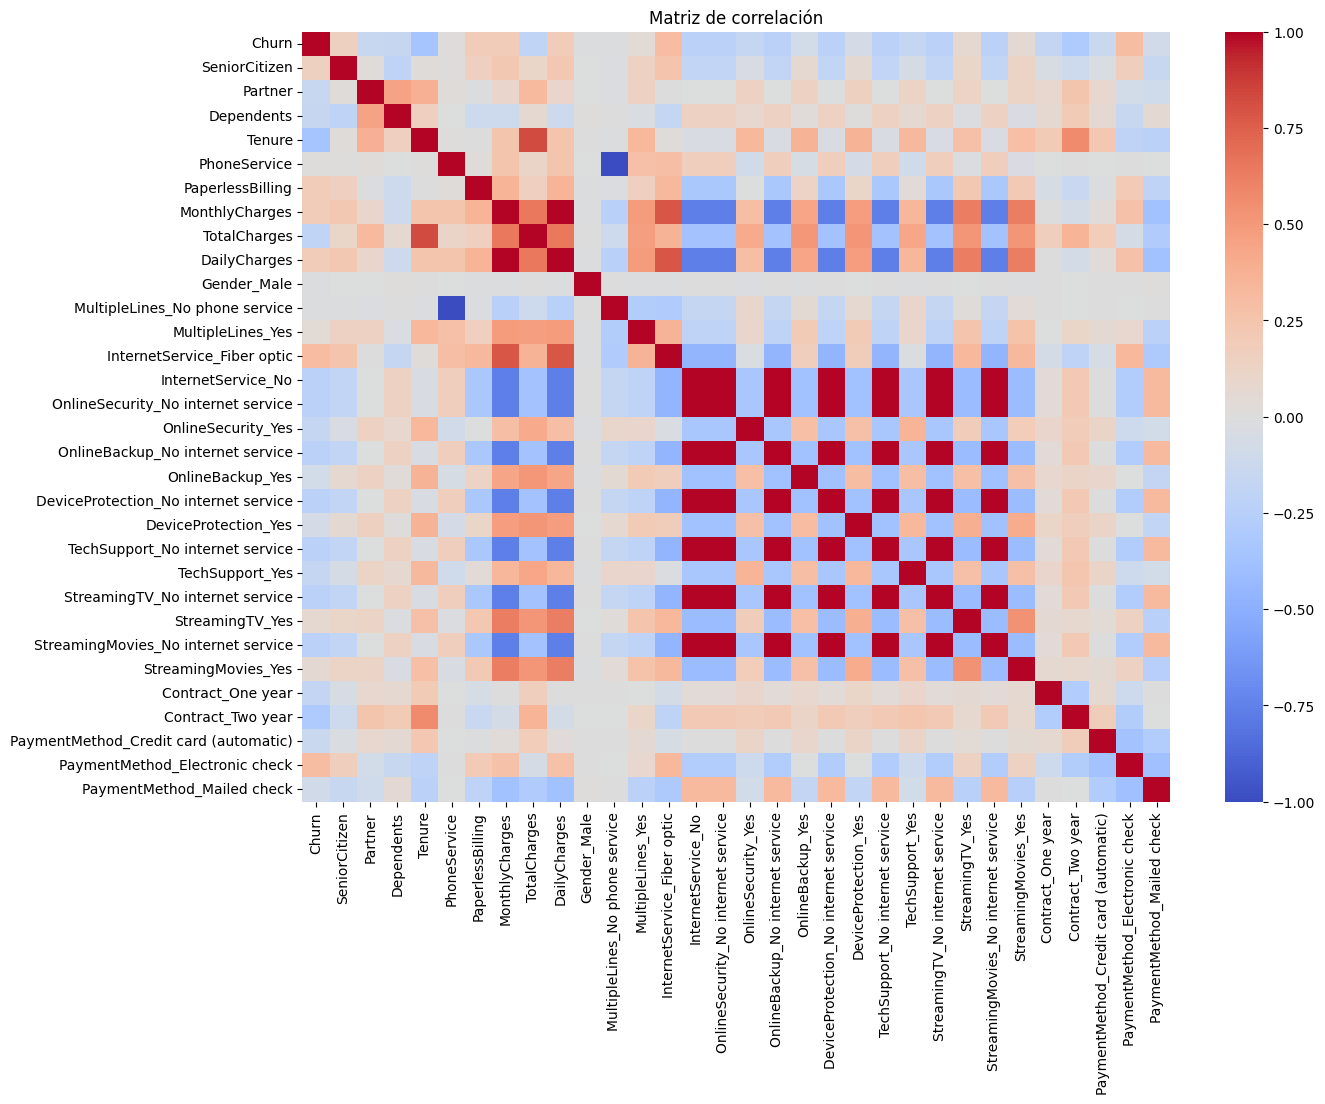

In [134]:
# Visualizar la matriz de correlación para identificar relaciones entre las variables
# y detectar cuáles están más relacionadas con la cancelación de clientes (Churn)
corr_matrix = df.corr()
corr_matrix

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [135]:
# Analizar específicamente la correlación de todas las variables con Churn
# Esto permite identificar las variables más importantes para el modelo predictivo

corr_churn = df.corr()["Churn"].sort_values(ascending=False)
print(corr_churn)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
DailyCharges                             0.192858
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService                             0.011691
Gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport_Yes                         -0.164716


## Conclusión del análisis de correlación

El análisis de correlación permitió identificar qué variables tienen mayor relación con la cancelación de clientes (Churn). Se observa que **InternetService_Fiber optic**, **PaymentMethod_Electronic check**, **MonthlyCharges**, **DailyCharges** y **PaperlessBilling** presentan correlaciones positivas con Churn, lo que indica que estos factores están asociados con una mayor probabilidad de cancelación. En particular, los clientes que utilizan internet de fibra óptica, que tienen cargos mensuales más altos o que utilizan el método de pago *electronic check* tienden a presentar mayores tasas de cancelación.

Por otro lado, variables como **Tenure**, **Contract_Two year**, **Contract_One year**, **OnlineSecurity_Yes** y **TechSupport_Yes** muestran correlaciones negativas con Churn. Esto sugiere que los clientes con mayor antigüedad en la empresa, contratos de mayor duración y servicios adicionales de soporte o seguridad presentan una menor probabilidad de cancelar el servicio.

Entre todas las variables analizadas, **Tenure** destaca como una de las más relevantes, mostrando la correlación negativa más fuerte con Churn. Esto indica que cuanto más tiempo permanece un cliente en la empresa, menor es la probabilidad de que cancele su servicio.

Además, algunas variables presentan correlaciones entre sí, como **MonthlyCharges** y **DailyCharges**, lo que indica que contienen información similar. Dependiendo del modelo utilizado, podría evaluarse mantener solo una de ellas para evitar redundancia en el modelo.

En general, los resultados sugieren que **la antigüedad del cliente, el tipo de contrato, el costo del servicio y el tipo de conexión a internet** son factores clave para comprender y predecir la cancelación de clientes.

## Preparación de datos para el modelado

In [136]:
# Eliminar variables altamente correlacionadas o redundantes
# Por ejemplo, DailyCharges puede eliminarse porque contiene información similar a MonthlyCharges

df = df.drop(columns=["DailyCharges"])

In [137]:
# Separar las variables predictoras (X) y la variable objetivo (y)
# Churn es la variable que queremos predecir

X = df.drop("Churn", axis=1)
y = df["Churn"]

## Análisis Dirigido: Relación entre variables clave y cancelación de clientes

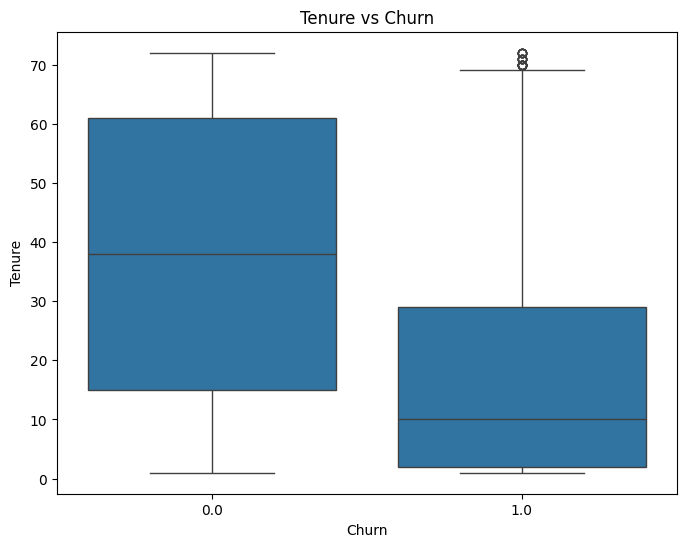

In [138]:
# Analizar la relación entre el tiempo de permanencia (Tenure)
# y la cancelación de clientes utilizando un boxplot

plt.figure(figsize=(8,6))
sns.boxplot(x="Churn", y="Tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

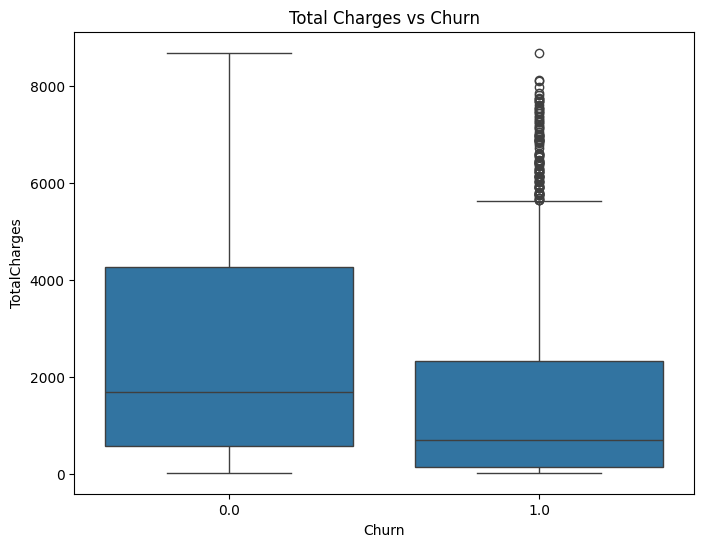

In [139]:
# Analizar la relación entre el gasto total del cliente (TotalCharges)
# y la cancelación utilizando un boxplot

plt.figure(figsize=(8,6))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges vs Churn")
plt.show()

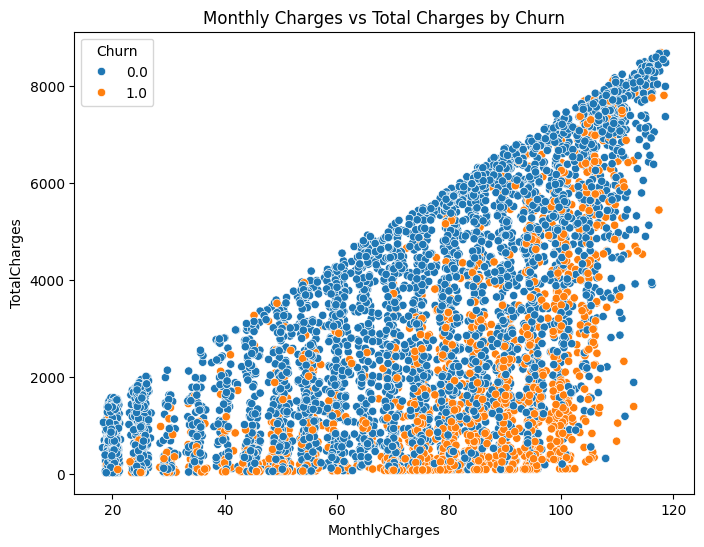

In [140]:
# Visualizar la relación entre los cargos mensuales y el gasto total
# diferenciando los clientes que cancelaron y los que no

plt.figure(figsize=(8,6))
sns.scatterplot(x="MonthlyCharges", y="TotalCharges", hue="Churn", data=df)
plt.title("Monthly Charges vs Total Charges by Churn")
plt.show()

## Separación de Datos

In [141]:
# División del dataset en conjuntos de entrenamiento y prueba para evaluar el modelo

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,   # variables predictoras
    y,          # variable objetivo (Churn)
    test_size=0.2,   # 20% prueba
    random_state=42
)



print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (5625, 30)
Tamaño prueba: (1407, 30)


In [142]:
# Estandarizar las variables numéricas para modelos sensibles a la escala
# como KNN, SVM, Regresión Logística o Redes Neuronales

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Creación y evaluación de modelos

### Modelo 1: Regresión Logística (requiere normalización)


Accuracy Regresión Logística: 0.7960199004975125

Reporte de clasificación:

              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1033
         1.0       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



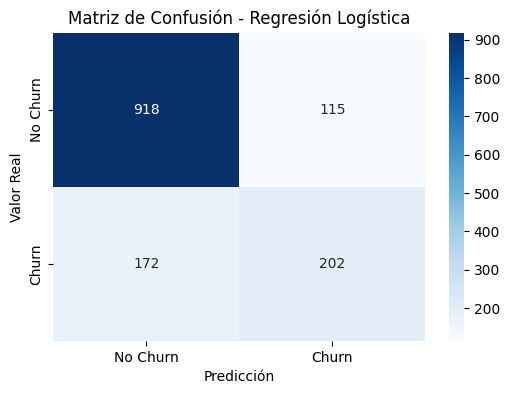

In [143]:
# Entrenamiento del modelo de Regresión Logística y evaluación de su desempeño mediante accuracy,
# reporte de clasificación y matriz de confusión

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear modelo
log_model = LogisticRegression(max_iter=1000)

# Entrenar
log_model.fit(X_train, y_train)

# Predicciones
y_pred_log = log_model.predict(X_test)

# Evaluación
print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_log))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)

# Gráfico
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.xticks([0.5,1.5], ["No Churn", "Churn"])
plt.yticks([0.5,1.5], ["No Churn", "Churn"])

plt.show()

### Modelo 2: Random Forest (no necesita normalización)





Accuracy Random Forest: 0.7818052594171997

Reporte de clasificación:

              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1033
         1.0       0.62      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407


Matriz de confusión:

[[929 104]
 [203 171]]


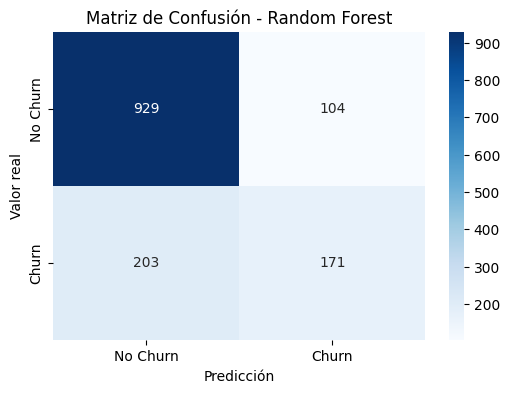

In [144]:
# Entrenamiento del modelo Random Forest para predecir la cancelación de clientes
# y evaluación de su desempeño mediante accuracy, reporte de clasificación y matriz de confusión

from sklearn.ensemble import RandomForestClassifier

# Crear modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Evaluación
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

print("\nMatriz de confusión:\n")
print(cm)

# Visualización
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

### Conclusión modelos

En este análisis se desarrollaron dos modelos de clasificación para predecir la cancelación de clientes (churn) en Telecom X: **Regresión Logística** y **Random Forest**. Ambos modelos fueron evaluados utilizando métricas de rendimiento como **accuracy, precision, recall, F1-score y matriz de confusión**.

El modelo de **Regresión Logística obtuvo el mejor desempeño general**, alcanzando una exactitud aproximada del **79.6%**, ligeramente superior al **78.1%** obtenido por el modelo de Random Forest. Además, la Regresión Logística mostró un **mayor recall para la clase churn**, lo que indica una mejor capacidad para identificar clientes que realmente cancelan el servicio. Esto es especialmente importante en problemas de churn, donde detectar a tiempo a los clientes en riesgo permite implementar estrategias de retención.

Por otro lado, el modelo **Random Forest** mostró un desempeño similar en términos de accuracy, pero presentó un **recall menor para los clientes que cancelan**, lo que significa que dejó pasar más casos de churn sin detectar. Sin embargo, este modelo permite analizar la **importancia de las variables**, lo que aporta información valiosa para entender los factores que influyen en la cancelación.

En cuanto al comportamiento de los modelos, no se observan señales claras de **overfitting**, ya que ambos modelos presentan resultados razonables y consistentes en los datos de prueba. Tampoco se evidencia un **underfitting significativo**, aunque el desempeño moderado en la detección de churn sugiere que podrían explorarse modelos más complejos o ajustes de hiperparámetros para mejorar los resultados.

## Variables importantes

### Variables importantes en Regresión Logística

In [146]:
# Análisis de los coeficientes del modelo de Regresión Logística
# para identificar qué variables tienen mayor influencia en la predicción de churn

coeficientes = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print(coeficientes.head(10))

TotalCharges                      0.762711
InternetService_Fiber optic       0.549261
PaymentMethod_Electronic check    0.181594
PaperlessBilling                  0.176807
MultipleLines_Yes                 0.176481
StreamingTV_Yes                   0.155072
StreamingMovies_Yes               0.152699
SeniorCitizen                     0.087943
MultipleLines_No phone service    0.064075
DeviceProtection_Yes              0.030262
dtype: float64


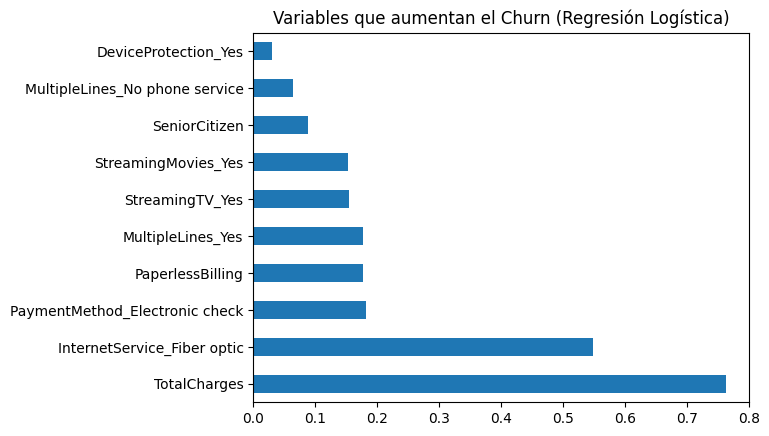

In [147]:
coeficientes.head(10).plot(kind="barh")
plt.title("Variables que aumentan el Churn (Regresión Logística)")
plt.show()

### Variables importantes en Random Forest

In [148]:
# Obtención de la importancia de las variables según el modelo Random Forest

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(10))

TotalCharges                      0.198296
MonthlyCharges                    0.167240
Tenure                            0.166761
PaymentMethod_Electronic check    0.042648
InternetService_Fiber optic       0.037215
Contract_Two year                 0.031642
Gender_Male                       0.027159
PaperlessBilling                  0.025886
OnlineSecurity_Yes                0.024622
Partner                           0.023191
dtype: float64


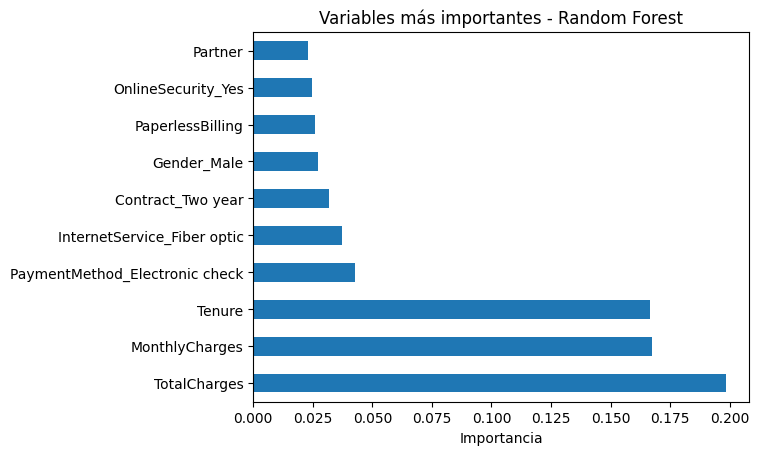

In [149]:
importances.head(10).plot(kind="barh")
plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.show()

### Conclusión sobre la importancia de las variables

Para comprender qué factores influyen en la cancelación de clientes, se analizaron las variables más relevantes en los dos modelos utilizados: **Regresión Logística** y **Random Forest**.

En el modelo de **Regresión Logística**, los coeficientes muestran que las variables con mayor influencia en la probabilidad de cancelación son **TotalCharges**, **InternetService_Fiber optic** y **PaymentMethod_Electronic check**. Esto sugiere que el nivel de gasto acumulado del cliente, el tipo de servicio de internet y el método de pago están fuertemente asociados con la probabilidad de churn. Además, variables relacionadas con servicios adicionales como **StreamingTV**, **StreamingMovies** y **MultipleLines** también presentan una influencia relevante en la predicción.

Por otro lado, el modelo **Random Forest** identificó como variables más importantes **TotalCharges**, **MonthlyCharges** y **Tenure**, lo que indica que los factores económicos y el tiempo de permanencia del cliente son determinantes para predecir la cancelación. También aparecen como variables influyentes el **método de pago (Electronic check)**, el **tipo de servicio de internet (Fiber optic)** y el **tipo de contrato**, lo que refuerza la idea de que la estructura del servicio contratado impacta en la decisión de permanecer o cancelar.

En conjunto, ambos modelos coinciden en destacar que variables relacionadas con **los costos del servicio, el tiempo como cliente y ciertas características del plan contratado** tienen un papel clave en la predicción del churn. Estos hallazgos sugieren que Telecom X debería prestar especial atención a clientes con **altos cargos mensuales, poca antigüedad o determinados tipos de servicios**, ya que podrían presentar un mayor riesgo de cancelación.


## Conclusión final y recomendaciones estratégicas

A partir del análisis exploratorio, el estudio de correlaciones y el entrenamiento de los modelos de Machine Learning, fue posible identificar los principales factores asociados a la cancelación de clientes (Churn) en Telecom X.

Los modelos entrenados permitieron predecir la probabilidad de cancelación y analizar qué variables tienen mayor impacto en esta decisión. En general, el modelo basado en árboles (Random Forest) mostró un mejor desempeño al capturar relaciones más complejas entre las variables, mientras que la regresión logística permitió interpretar con mayor claridad la influencia de cada factor en la cancelación.

Entre las variables más relevantes para predecir el churn se destacan:

- **Tenure (antigüedad del cliente)**: fue uno de los factores más influyentes. Los clientes con menor tiempo en la empresa presentan una mayor probabilidad de cancelar el servicio.
- **Tipo de contrato**: los clientes con contratos mensuales muestran una mayor tendencia a cancelar en comparación con aquellos que poseen contratos de uno o dos años.
- **MonthlyCharges (cargos mensuales)**: cargos mensuales más elevados están asociados con mayores tasas de cancelación.
- **InternetService (Fiber optic)**: los clientes con servicio de fibra óptica presentan mayores niveles de churn, posiblemente debido al costo del servicio o a expectativas de calidad.
- **PaymentMethod (Electronic check)**: este método de pago aparece con mayor frecuencia entre los clientes que cancelan.

Por otro lado, variables como **OnlineSecurity**, **TechSupport** y contratos de mayor duración se asocian con una menor probabilidad de cancelación, lo que sugiere que estos servicios pueden aumentar la fidelización de los clientes.

### Estrategias de retención sugeridas

Con base en los resultados obtenidos, se proponen algunas estrategias que podrían ayudar a reducir la tasa de cancelación:

- **Programas de fidelización para nuevos clientes**, especialmente durante los primeros meses de servicio, donde el riesgo de cancelación es mayor.
- **Incentivar contratos de mayor duración**, ofreciendo descuentos o beneficios a clientes que migren de contratos mensuales a contratos anuales o bianuales.
- **Revisión de la estructura de precios**, particularmente para clientes con cargos mensuales elevados.
- **Promoción de servicios adicionales**, como soporte técnico y seguridad en línea, que se relacionan con una menor probabilidad de cancelación.
- **Mejorar la experiencia del servicio de fibra óptica**, investigando posibles problemas de calidad o satisfacción.

En conclusión, el uso de modelos predictivos permite no solo anticipar qué clientes tienen mayor riesgo de cancelar, sino también identificar los factores que influyen en esta decisión. Esta información puede utilizarse para diseñar estrategias de retención más efectivas y mejorar la satisfacción y fidelidad de los clientes.